# Feature selection

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import sys
sys.path.append("..")

from src.config import RAW_DATA_DIR
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, f_regression
from matplotlib import pyplot as plt

Feature Scores (sorted):


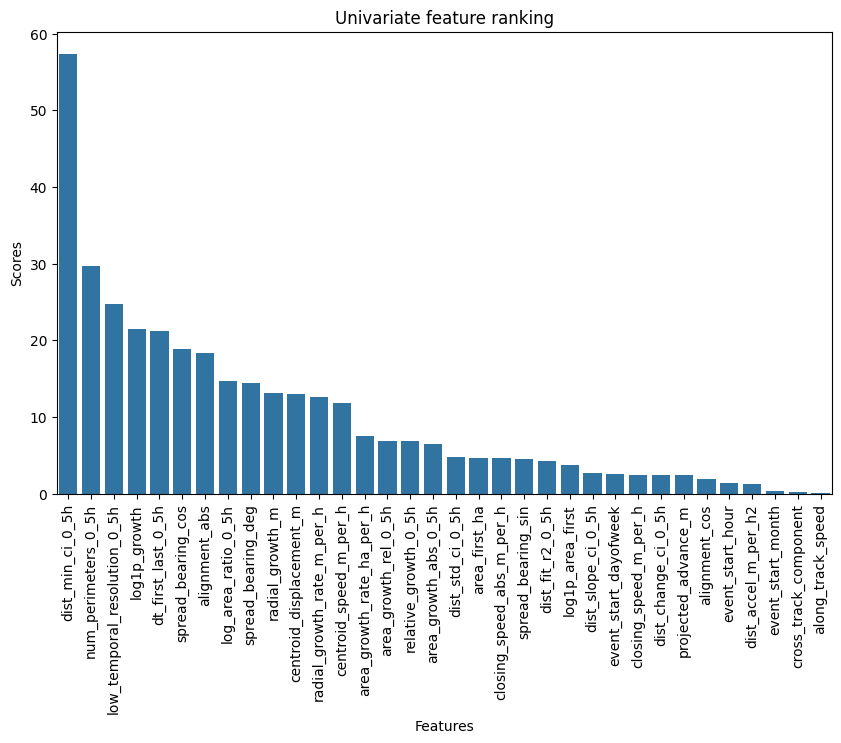

Selected Features:
Index(['num_perimeters_0_5h', 'dt_first_last_0_5h',
       'low_temporal_resolution_0_5h', 'log1p_growth', 'dist_min_ci_0_5h'],
      dtype='str')


In [18]:

df = pd.read_csv(RAW_DATA_DIR / "train.csv")

unused = ["event", "time_to_hit_hours", "event_id"]

X_train, X_test, y_train, y_test = train_test_split(
    df[[c for c in df.columns if c not in unused]], 
    df['event'], 
    test_size=0.2, 
    random_state=222,
    stratify=df['event']
)

# Perform univariate feature selection
selector = SelectKBest(score_func=f_regression, k=5)
X_new = selector.fit_transform(X_train, y_train)

# Get the selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = X_train.columns[selected_indices]

# Get the feature scores
scores = selector.scores_
scores_sorted = sorted(zip(X_train.columns, scores), key=lambda x: x[1], reverse=True)
print("Feature Scores (sorted):")
feature_scores = pd.DataFrame(scores_sorted, columns=["Feature", "Score"])

# Plot the feature scores
plt.figure(figsize=(10, 6))
sns.barplot(x="Feature", y="Score", data=feature_scores)
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Scores')
plt.title('Univariate feature ranking')
plt.show()

print("Selected Features:")
print(selected_features)


In [22]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold

print(y_train.value_counts())
y_train = y_train.astype(int)

estimator = LinearRegression()
skfold = StratifiedKFold(n_splits=5, shuffle=False)
selector = RFE(estimator=estimator, n_features_to_select=5, step=1)
selector.fit(X_train, y_train)

selected_indices = selector.get_support(indices=True)
selected_features = X_train.columns[selected_indices]

print(f"Wybrana liczba cech: {selector.n_features_}")
print("Wybrane cechy:")
for i in range(X_train.shape[1]):
    if selector.support_[i]:
        print(f"- {X_train.columns[i]}")
        


event
0    121
1     55
Name: count, dtype: int64
Wybrana liczba cech: 5
Wybrane cechy:
- low_temporal_resolution_0_5h
- log1p_growth
- spread_bearing_sin
- dist_fit_r2_0_5h
- alignment_cos


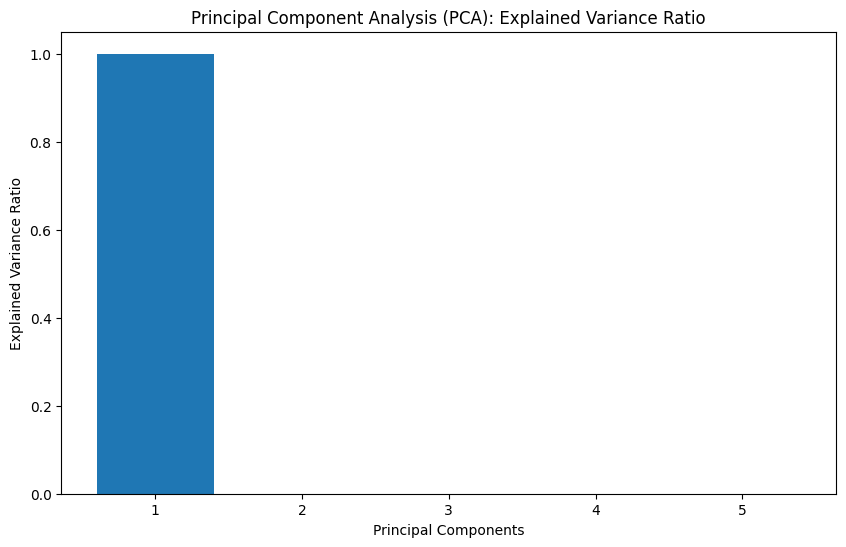

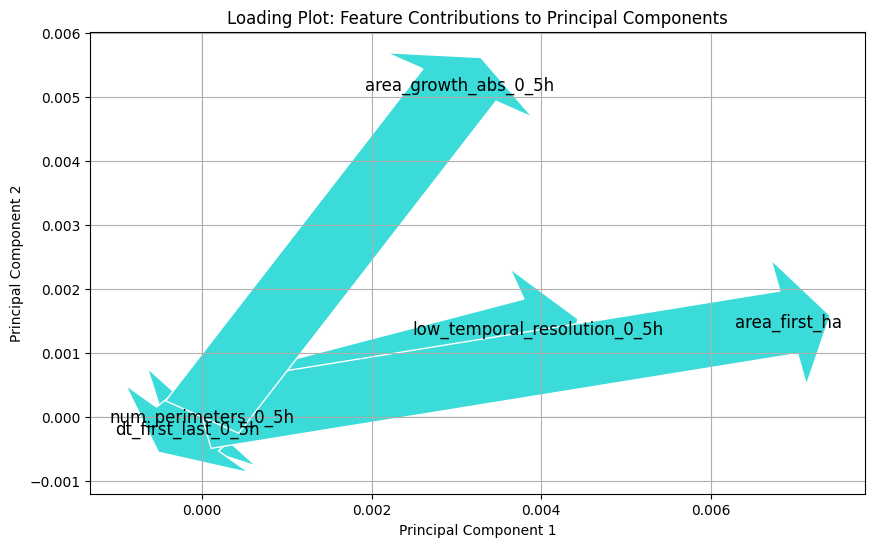

In [24]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X = X_train[[c for c in X_train.columns if c != "event_id"]]
X_new = pca.fit_transform(X)

# Get the explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Principal Component Analysis (PCA): Explained Variance Ratio')
plt.show()

# Get the loadings (principal component vectors)
loadings = pca.components_

# Create a loading plot
plt.figure(figsize=(10, 6))
for i, (loading, feature_name) in enumerate(zip(loadings, X.columns)):
    plt.arrow(0, 0, loading[0], loading[1], head_width=0.002, head_length=0.0005, fc="#3ADBD8", ec="#FFFFFF")
    plt.text(loading[0], loading[1], feature_name, fontsize=12, ha='center', va='center', color='black')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.1)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.1)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Loading Plot: Feature Contributions to Principal Components')
plt.grid(True)
plt.show()


/Users/ms/Documents/golem/wdis-wildfire-forecasting/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.842e+00, tolerance: 3.781e-03
  model = cd_fast.enet_coordinate_descent(


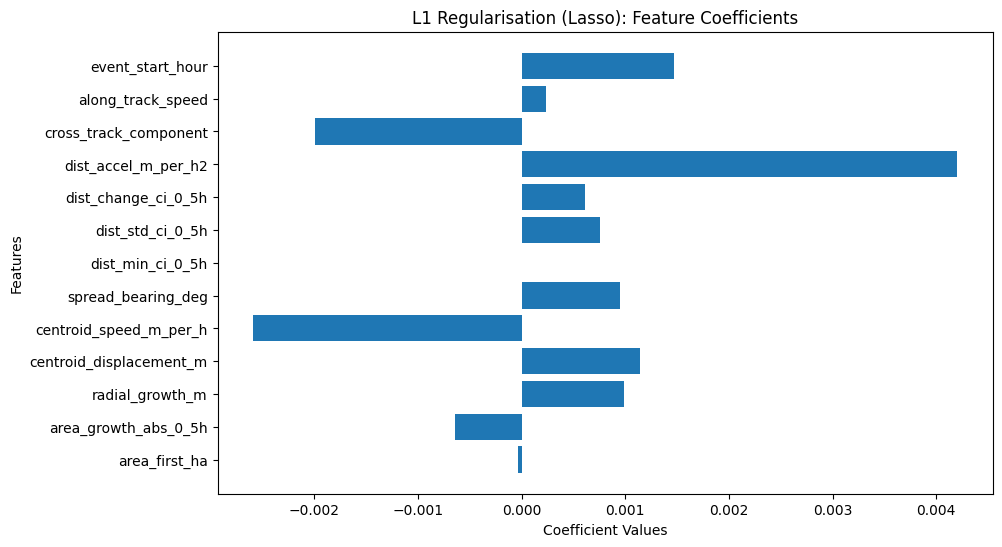

Selected Features:
Index(['area_first_ha', 'area_growth_abs_0_5h', 'radial_growth_m',
       'centroid_displacement_m', 'centroid_speed_m_per_h',
       'spread_bearing_deg', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h',
       'dist_change_ci_0_5h', 'dist_accel_m_per_h2', 'cross_track_component',
       'along_track_speed', 'event_start_hour'],
      dtype='str')


In [ ]:
from sklearn.linear_model import Lasso

# Perform L1 regularisation (Lasso)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

# Get the non-zero feature coefficients
nonzero_coefs = lasso.coef_
selected_indices = nonzero_coefs != 0
selected_features = X_train.columns[selected_indices]
nonzero_coefs = nonzero_coefs[selected_indices]

# Plot the feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(range(len(nonzero_coefs)), nonzero_coefs, tick_label=selected_features)
plt.xlabel('Coefficient Values')
plt.ylabel('Features')
plt.title('L1 Regularisation (Lasso): Feature Coefficients')
plt.show()

print("Selected Features:")
print(selected_features)


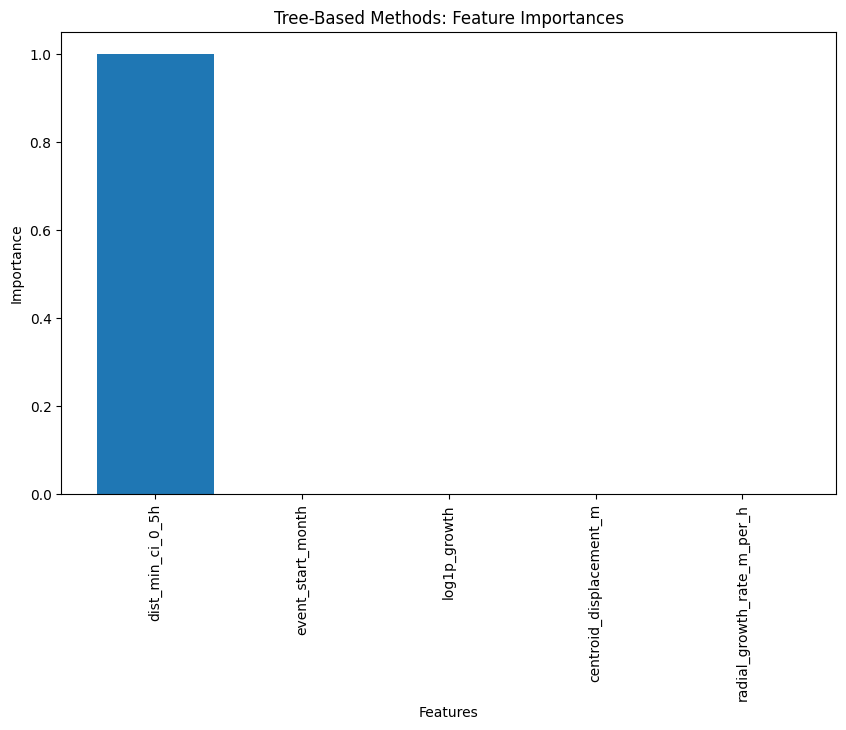

Selected Features:
Index(['dist_min_ci_0_5h', 'event_start_month', 'log1p_growth',
       'centroid_displacement_m', 'radial_growth_rate_m_per_h'],
      dtype='str')
Feature Importances:
[1. 0. 0. 0. 0.]


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Perform feature selection using Random Forest
forest = RandomForestRegressor(n_estimators=400)
forest.fit(X_train, y_train)

# Get feature importances
importances = forest.feature_importances_

# Sort feature importances in descending order
sorted_indices = importances.argsort()[::-1]

# Select the top k features
k = 5
selected_features = X_train.columns[sorted_indices[:k]]
top_importances = importances[sorted_indices[:k]]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(len(top_importances)), top_importances, tick_label=selected_features)
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Tree-Based Methods: Feature Importances')
plt.show()

print("Selected Features:")
print(selected_features)
print("Feature Importances:")
print(top_importances)